In [152]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# census_income = fetch_ucirepo(id=20) 
  
# # data (as pandas dataframes) 
# X = census_income.data.features 
# y = census_income.data.targets 
  
# # metadata 
# print(census_income.metadata) 
  
# # variable information 
# print(census_income.variables) 


In [153]:
# df = X.copy()
# df['income'] = y

In [154]:
import pandas as pd

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

train = pd.read_csv(
    '../data/adult.data',
    header=None,
    names=columns,
    skipinitialspace=True
)

test = pd.read_csv(
    '../data/adult.test',
    header=None,
    names=columns,
    skipinitialspace=True,
    skiprows=1
)

print(train.shape)

df = pd.concat([train, test], ignore_index=True)

(32561, 15)


In [155]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [157]:
df.shape

(48842, 15)

In [158]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,48842,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,48842,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [160]:
# print("Workclass ?:", (df['workclass'] == '?').sum())
# print("Occupation ?:", (df['occupation'] == '?').sum())
# print("Native country ?:", (df['native-country'] == '?').sum())

In [161]:
df['income'].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

##### There is inconsistency in the target feature. We have to later change this into a 2 class problem

In [162]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [163]:
df.select_dtypes(include='object').nunique()

workclass          9
education         16
marital-status     7
occupation        15
relationship       6
race               5
sex                2
native-country    42
income             4
dtype: int64

In [164]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

 education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

 marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 occupation
occupation
Prof-specialty     

#### Missing value count is shown as 0 for all the rows. But there is something else that came into attention in the above step. 3 features have "?" value. On reasearch, found out that UCI raw files save dont save missing values as NaN instead as ?. So we have to treat these as missing values only.

In [165]:
df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [166]:
df.select_dtypes(include='number').skew()

age                0.557580
fnlwgt             1.438892
education-num     -0.316525
capital-gain      11.894659
capital-loss       4.569809
hours-per-week     0.238750
dtype: float64

#### Data is extremely skewed in case of capital-gain and capital-loss. Not uniformly distributed

### Till now, we identified missing values, duplicate rows, there is noise in data, class imbalance, target variable inconsistency, uneven distribution(skewness), correlated features etc. 

# EDA + Data Preparation

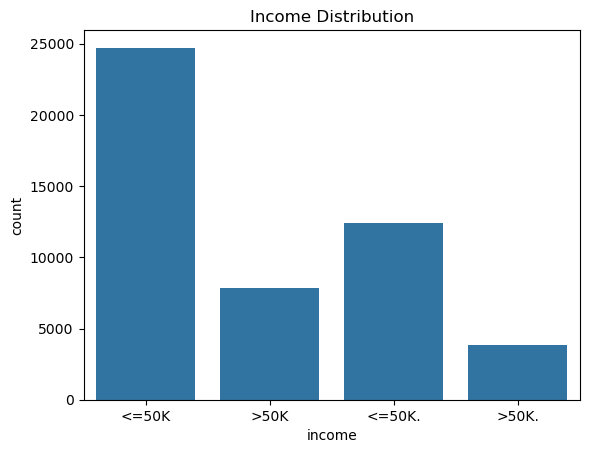

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='income')
plt.title('Income Distribution')
plt.show()

In [168]:
df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

df['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

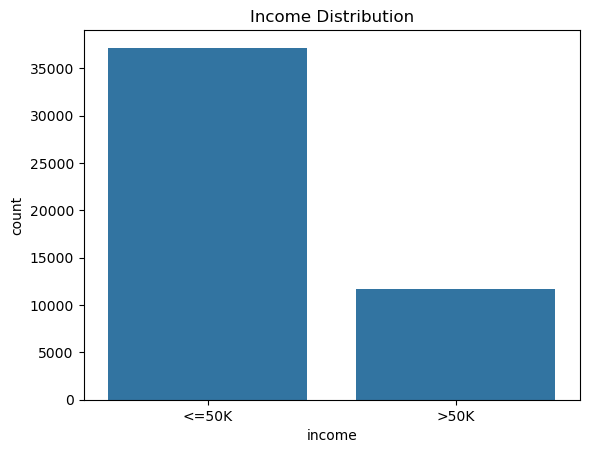

In [169]:
sns.countplot(data=df, x='income')
plt.title('Income Distribution')
plt.show()

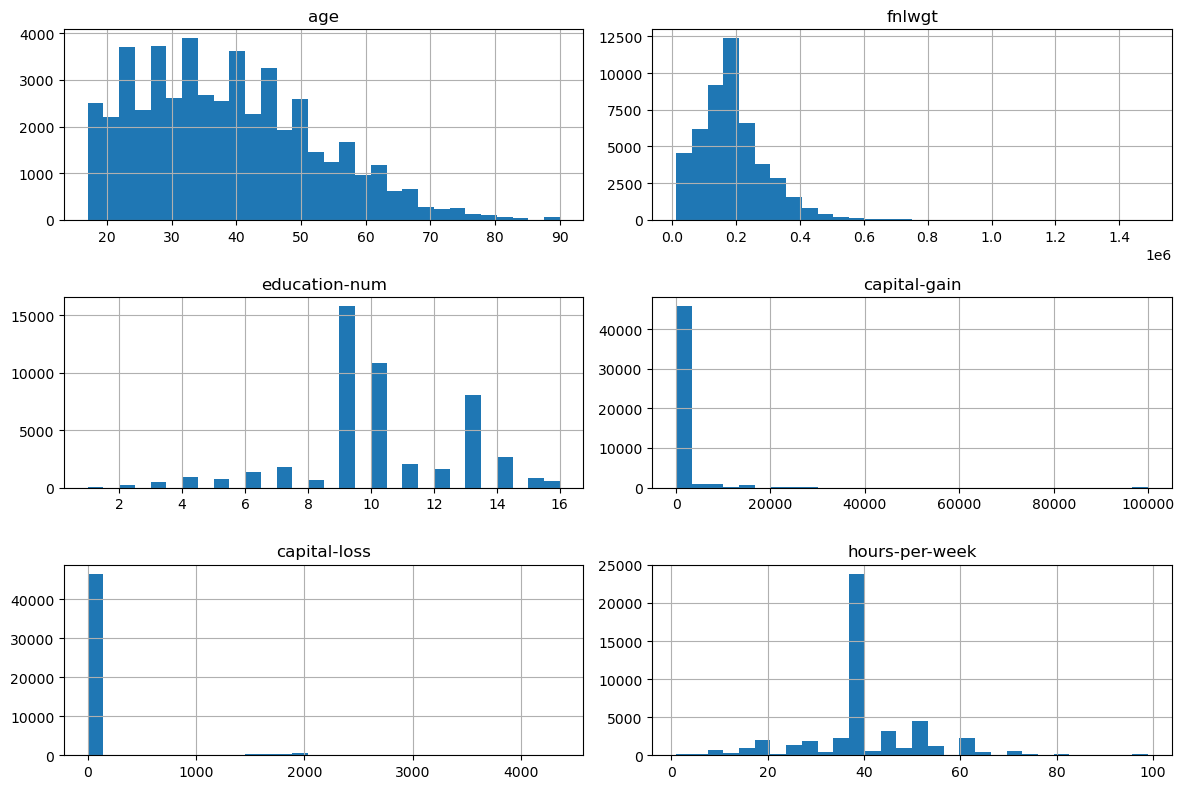

In [170]:
df.select_dtypes(include='number').hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

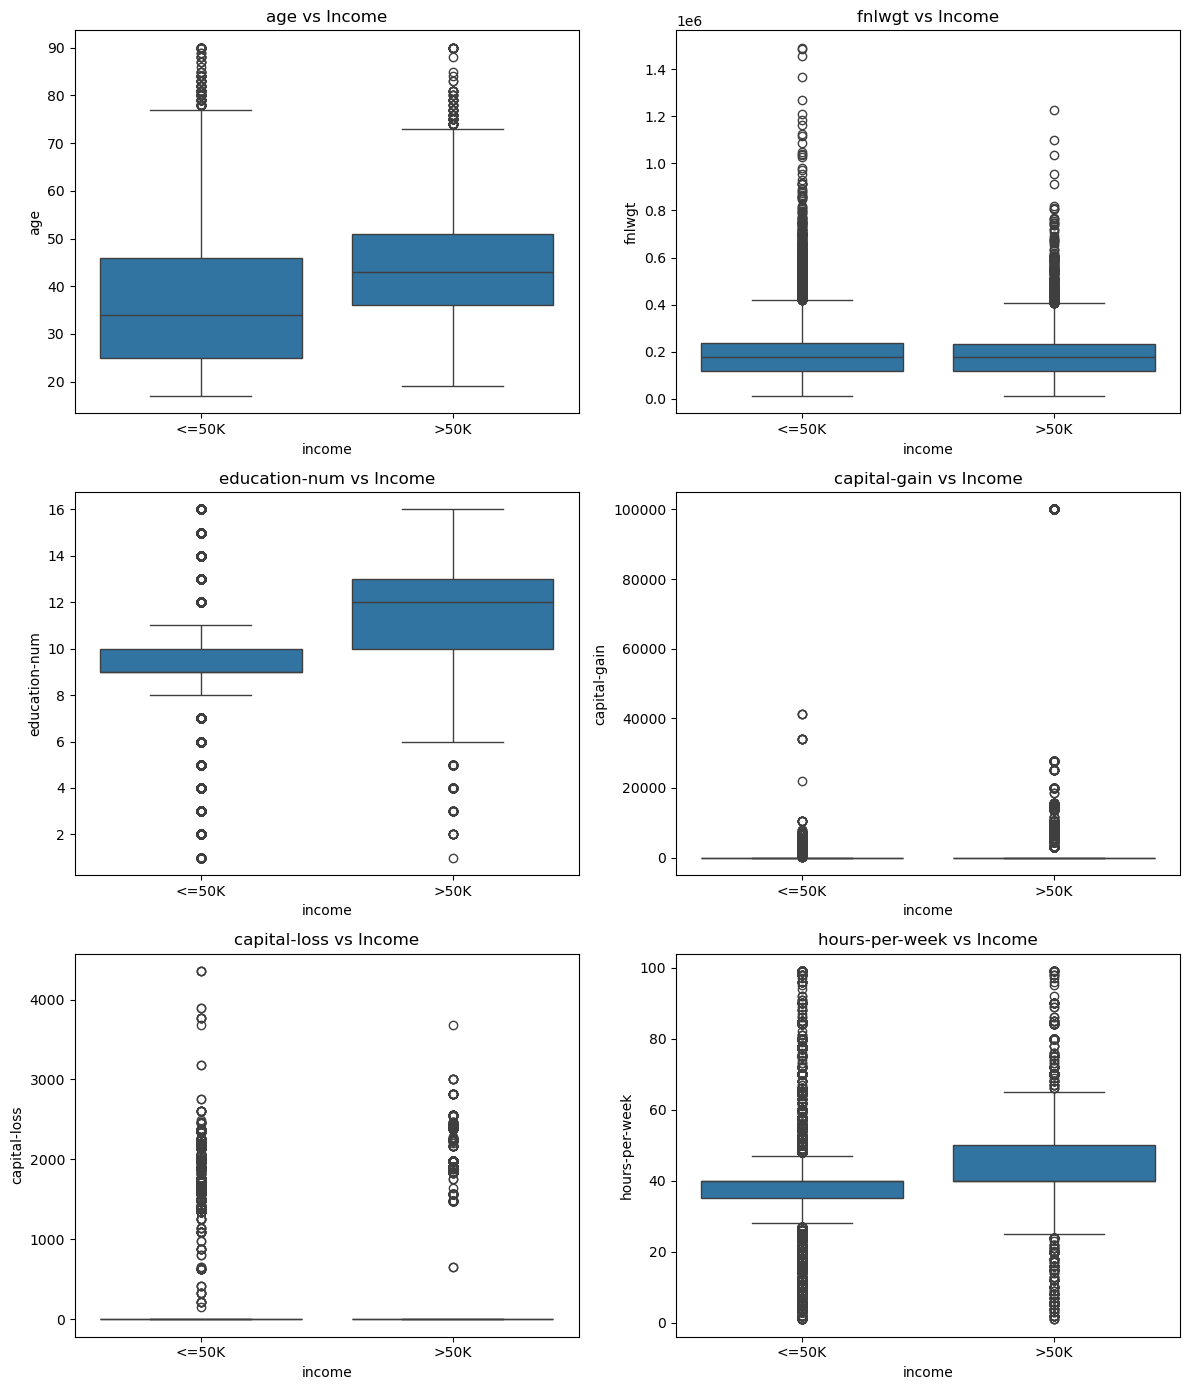

In [171]:
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='income', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Income')

plt.tight_layout()
plt.show()

### heavy overalpping in hours per week and fnlwgt, so it may have limited predictive value

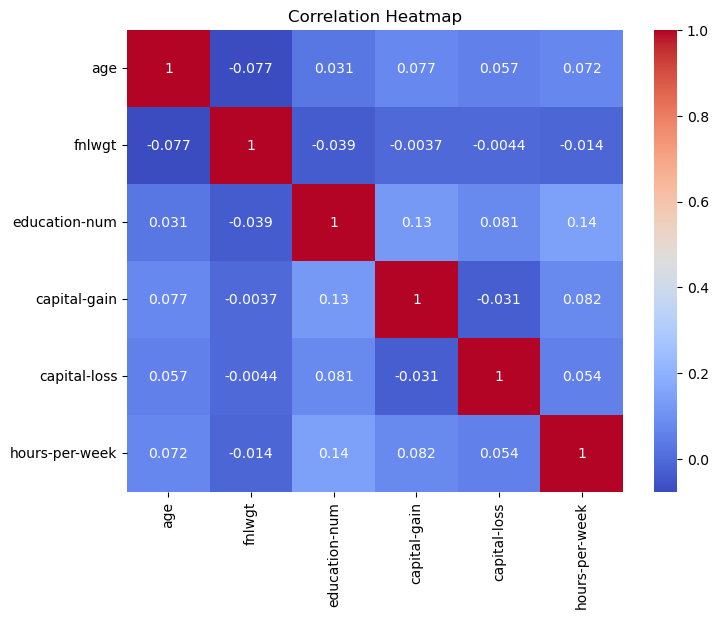

In [172]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [173]:
import pandas as pd

pd.crosstab(df['education'], df['income'], normalize='index') * 100

income,<=50K,>50K
education,,
10th,93.736501,6.263499
11th,94.922737,5.077263
12th,92.694064,7.305936
1st-4th,96.761134,3.238866
5th-6th,94.695481,5.304519
7th-8th,93.507853,6.492147
9th,94.576720,5.423280
Assoc-acdm,74.203623,25.796377
Assoc-voc,74.672489,25.327511


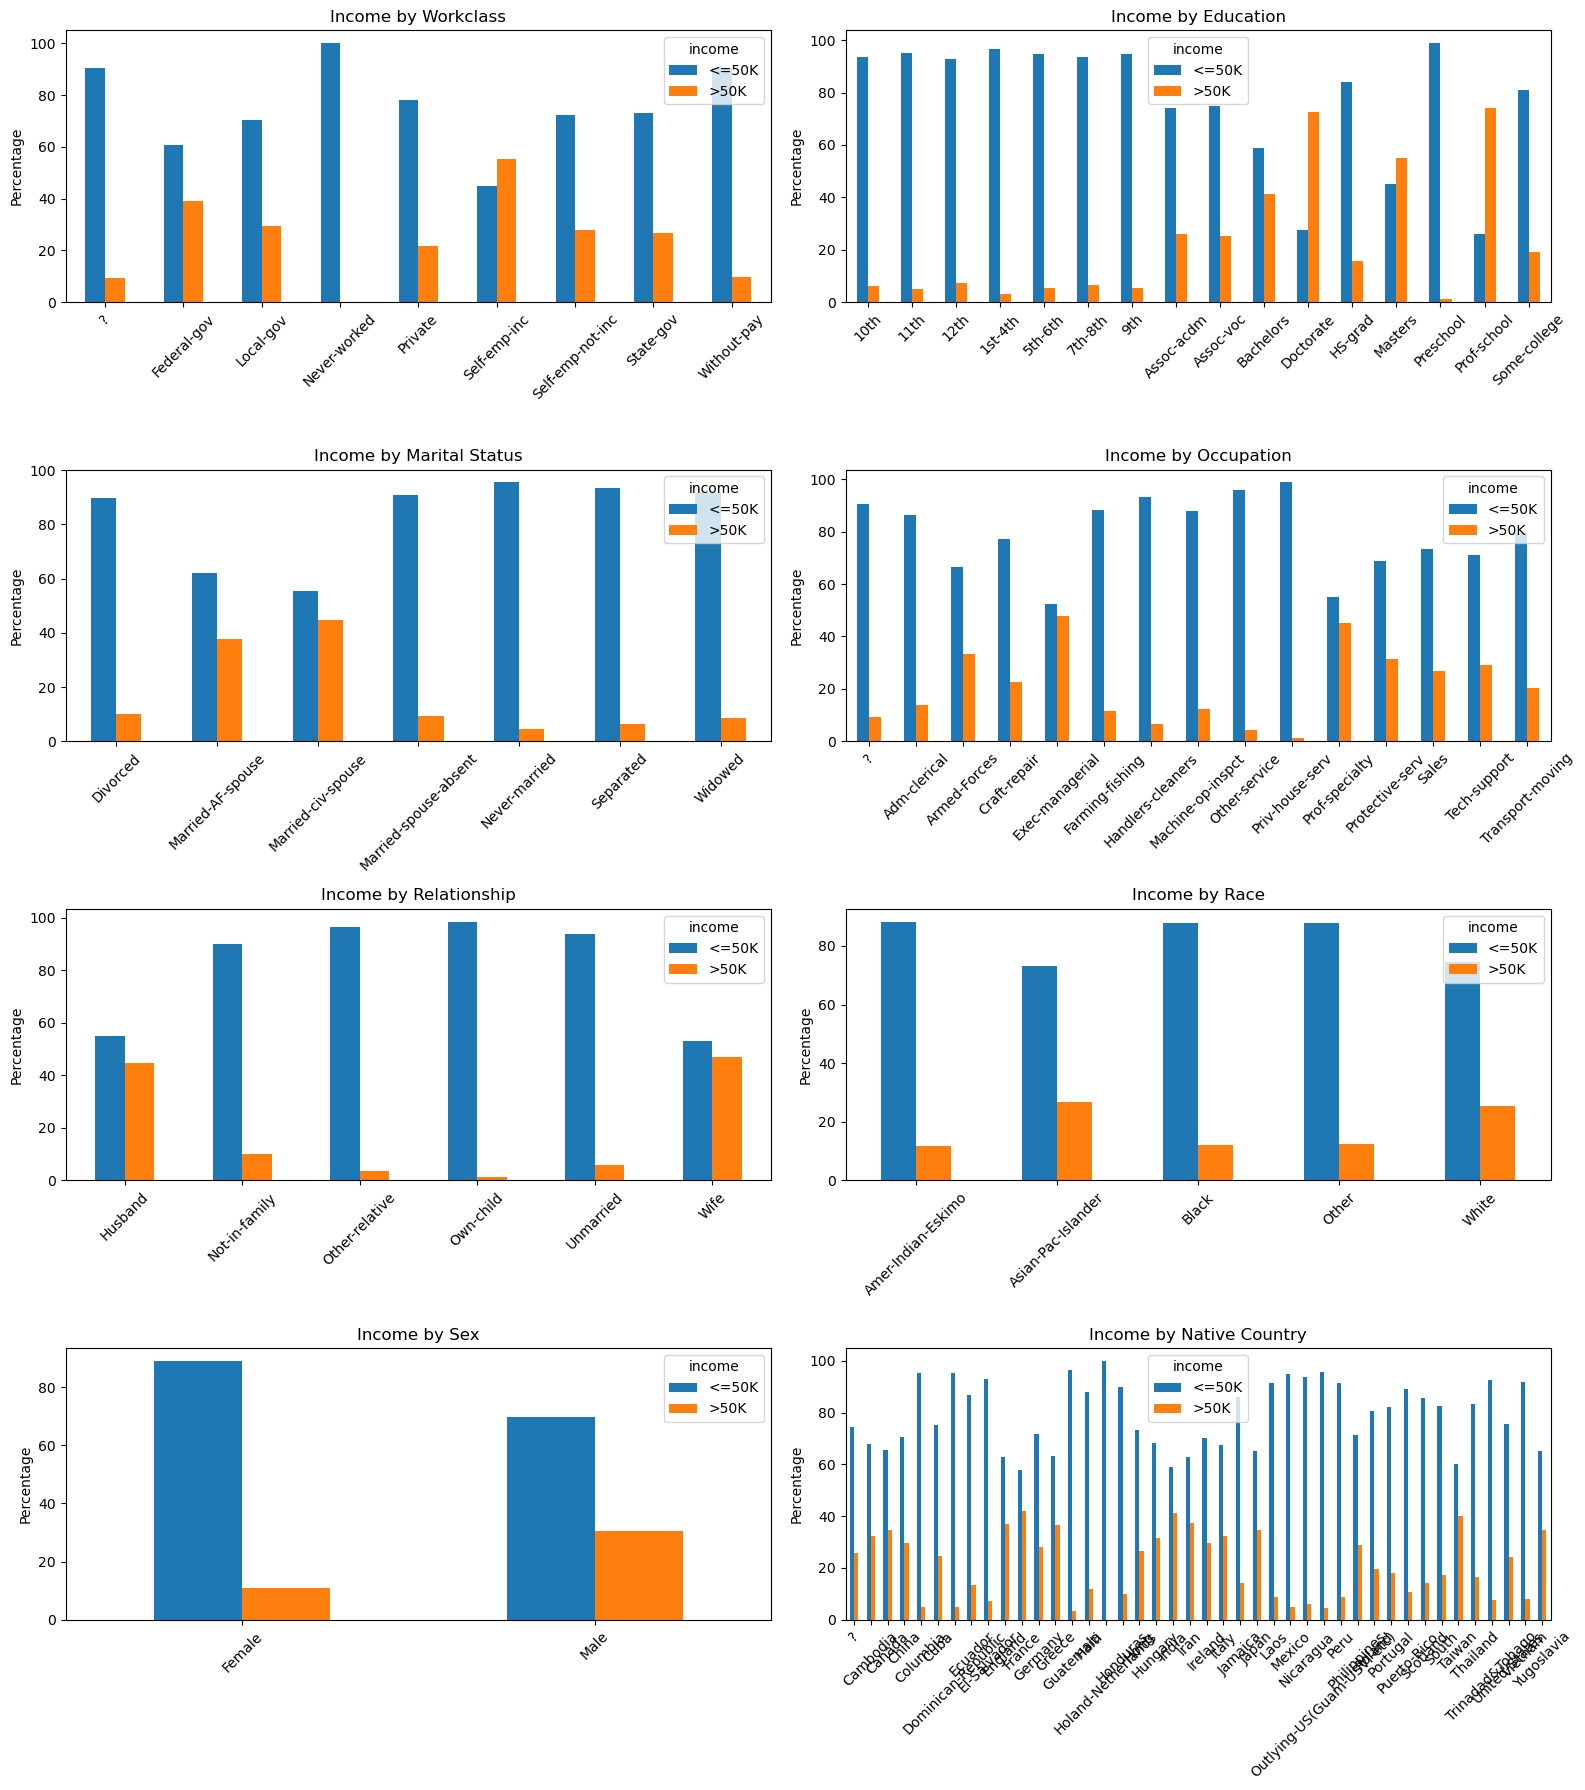

In [174]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

# Workclass
workclass_income = pd.crosstab(
    df['workclass'], df['income'], normalize='index'
) * 100

workclass_income.plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Income by Workclass')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Education
education_income = pd.crosstab(
    df['education'], df['income'], normalize='index'
) * 100

education_income.plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Income by Education')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Marital Status
marital_income = pd.crosstab(
    df['marital-status'], df['income'], normalize='index'
) * 100

marital_income.plot(
    kind='bar', ax=axes[2]
)
axes[2].set_title('Income by Marital Status')
axes[2].set_ylabel('Percentage')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Occupation
occupation_income = pd.crosstab(
    df['occupation'], df['income'], normalize='index'
) * 100

occupation_income.plot(
    kind='bar', ax=axes[3]
)
axes[3].set_title('Income by Occupation')
axes[3].set_ylabel('Percentage')
axes[3].set_xlabel('')
axes[3].tick_params(axis='x', rotation=45)

# Relationship
relationship_income = pd.crosstab(
    df['relationship'], df['income'], normalize='index'
) * 100

relationship_income.plot(
    kind='bar', ax=axes[4]
)
axes[4].set_title('Income by Relationship')
axes[4].set_ylabel('Percentage')
axes[4].set_xlabel('')
axes[4].tick_params(axis='x', rotation=45)

# Race
race_income = pd.crosstab(
    df['race'], df['income'], normalize='index'
) * 100

race_income.plot(
    kind='bar', ax=axes[5]
)
axes[5].set_title('Income by Race')
axes[5].set_ylabel('Percentage')
axes[5].set_xlabel('')
axes[5].tick_params(axis='x', rotation=45)

# Sex
sex_income = pd.crosstab(
    df['sex'], df['income'], normalize='index'
) * 100

sex_income.plot(
    kind='bar', ax=axes[6]
)
axes[6].set_title('Income by Sex')
axes[6].set_ylabel('Percentage')
axes[6].set_xlabel('')
axes[6].tick_params(axis='x', rotation=45)

# Native Country
country_income = pd.crosstab(
    df['native-country'], df['income'], normalize='index'
) * 100

country_income.plot(
    kind='bar', ax=axes[7]
)
axes[7].set_title('Income by Native Country')
axes[7].set_ylabel('Percentage')
axes[7].set_xlabel('')
axes[7].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [175]:
dupes = df.duplicated().sum()
print("No of duplicate rows: ",dupes)

No of duplicate rows:  52


In [176]:
df[df.duplicated()].head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K


In [177]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [178]:
# NUMBER OF ZERO VALUES IN EACH FEATURE

print("Zero Values in Each Feature")

zero_values = (df == 0).sum()

display(zero_values)

Zero Values in Each Feature


age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
marital-status        0
occupation            0
relationship          0
race                  0
sex                   0
capital-gain      44755
capital-loss      46508
hours-per-week        0
native-country        0
income                0
dtype: int64

##### Having zero values in these 2 features is valid. So no need to replace it with NaN

In [179]:
# Treating ? values

print("Workclass:", (df['workclass'] == '?').sum())
print("Occupation:", (df['occupation'] == '?').sum())
print("Native country:", (df['native-country'] == '?').sum())


Workclass: 2795
Occupation: 2805
Native country: 856


In [180]:
import numpy as np

df = df.replace('?', np.nan)

In [181]:
df.isnull().sum()

age                  0
workclass         2795
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2805
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     856
income               0
dtype: int64

##### Now we have missing values in 3 features which can be treated later using imputation

In [182]:
df.shape

(48790, 15)

In [183]:
# splitting data into train and test to prevent data leakage during further processing 

train = df.iloc[:32561].copy()
test = df.iloc[32561:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (32561, 15)
Test shape: (16229, 15)


In [184]:
print("TRAIN")
print(train.isnull().sum())

print("\nTEST")
print(test.isnull().sum())

TRAIN
age                  0
workclass         1840
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1847
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

TEST
age                 0
workclass         955
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        958
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    273
income              0
dtype: int64
